In [1]:
# the goal of this notebook is to investigate spikes in activity that were noticed in yesterday's article

In [2]:
import pandas as pd
import plotly.express as px

In [3]:
def extract_state(location_name):

    for state in state_abbrev.keys():
        if state in location_name:
            return state

    return None

In [4]:
# state name (raw dat) to abbreviation (plotly needs) mapping
state_abbrev = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY'
}

# Time Series

I want to look at some of these states separately.

In [5]:
data = 'data/verdant_eye/ve_chatter_by_state_and_date_ice.csv'

tsdf = pd.read_csv(data)
tsdf.columns = ['state', 'date', 'count']
tsdf.head()

,state,date,count
0,Minnesota,2026-05-10,1
1,United States,2026-05-10,1
2,North America,2026-05-10,1
3,Bronx,2026-05-09,2
4,Asia,2026-05-09,2


In [6]:
tsdf['state'] = tsdf['state'].apply(extract_state)

tsdf = tsdf.dropna(subset=['state'])

tsdf = (
    tsdf.groupby(['state', 'date'])['count']
    .sum()
    .reset_index()
)

tsdf = tsdf.sort_values('count', ascending=False)

tsdf = tsdf.reset_index(drop=True)
tsdf.head()

,state,date,count
0,Minnesota,2026-01-18,156
1,Minnesota,2026-01-15,149
2,Minnesota,2026-01-24,148
3,Minnesota,2026-01-30,141
4,Minnesota,2026-01-25,140


In [7]:
tsdf.shape

(1786, 3)

In [8]:
def draw_state_chatter_counts(check_df):

    check_df = check_df.copy()
    state = check_df['state'].iloc[0]
    fig = px.bar(check_df, x='date', y='count', title='{} ICE Chatter Counts'.format(state))

    return fig.show()

In [9]:
check_df = tsdf[tsdf['state']=='Minnesota']
draw_state_chatter_counts(check_df)

# Multiple States Compared

Let's look at multiple states at once to compare how things are looking.

In [10]:
def draw_state_chatter_comparison(states):

    check_df = tsdf[tsdf['state'].isin(states)].sort_values('date')

    fig = px.line(check_df, x='date', y='count', color='state',
                  title='ICE Chatter Counts Compared by States')

    fig.update_traces(line=dict(width=2))

    return fig.show()

In [11]:
states = ['Minnesota', 'California', 'Oregon', 'Texas', 'New York']

draw_state_chatter_comparison(states)

In [12]:
tsdf.head()

,state,date,count
0,Minnesota,2026-01-18,156
1,Minnesota,2026-01-15,149
2,Minnesota,2026-01-24,148
3,Minnesota,2026-01-30,141
4,Minnesota,2026-01-25,140


In [13]:
pvt_df = pd.pivot_table(tsdf, values='count', index='state', columns='date' ).fillna(0).astype(int)

pvt_df = pvt_df.T

pvt_df.head()

state,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2026-01-15,1,0,0,0,11,2,2,0,7,0,...,0,0,0,5,2,0,0,4,0,0
2026-01-16,0,0,2,1,8,1,1,0,6,2,...,0,0,0,10,0,0,0,0,0,0
2026-01-17,0,0,1,0,3,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2026-01-18,0,0,1,0,15,1,0,0,11,0,...,0,0,0,5,1,0,5,2,3,0
2026-01-19,1,0,0,0,8,1,0,0,3,0,...,0,0,0,13,0,0,0,0,0,0


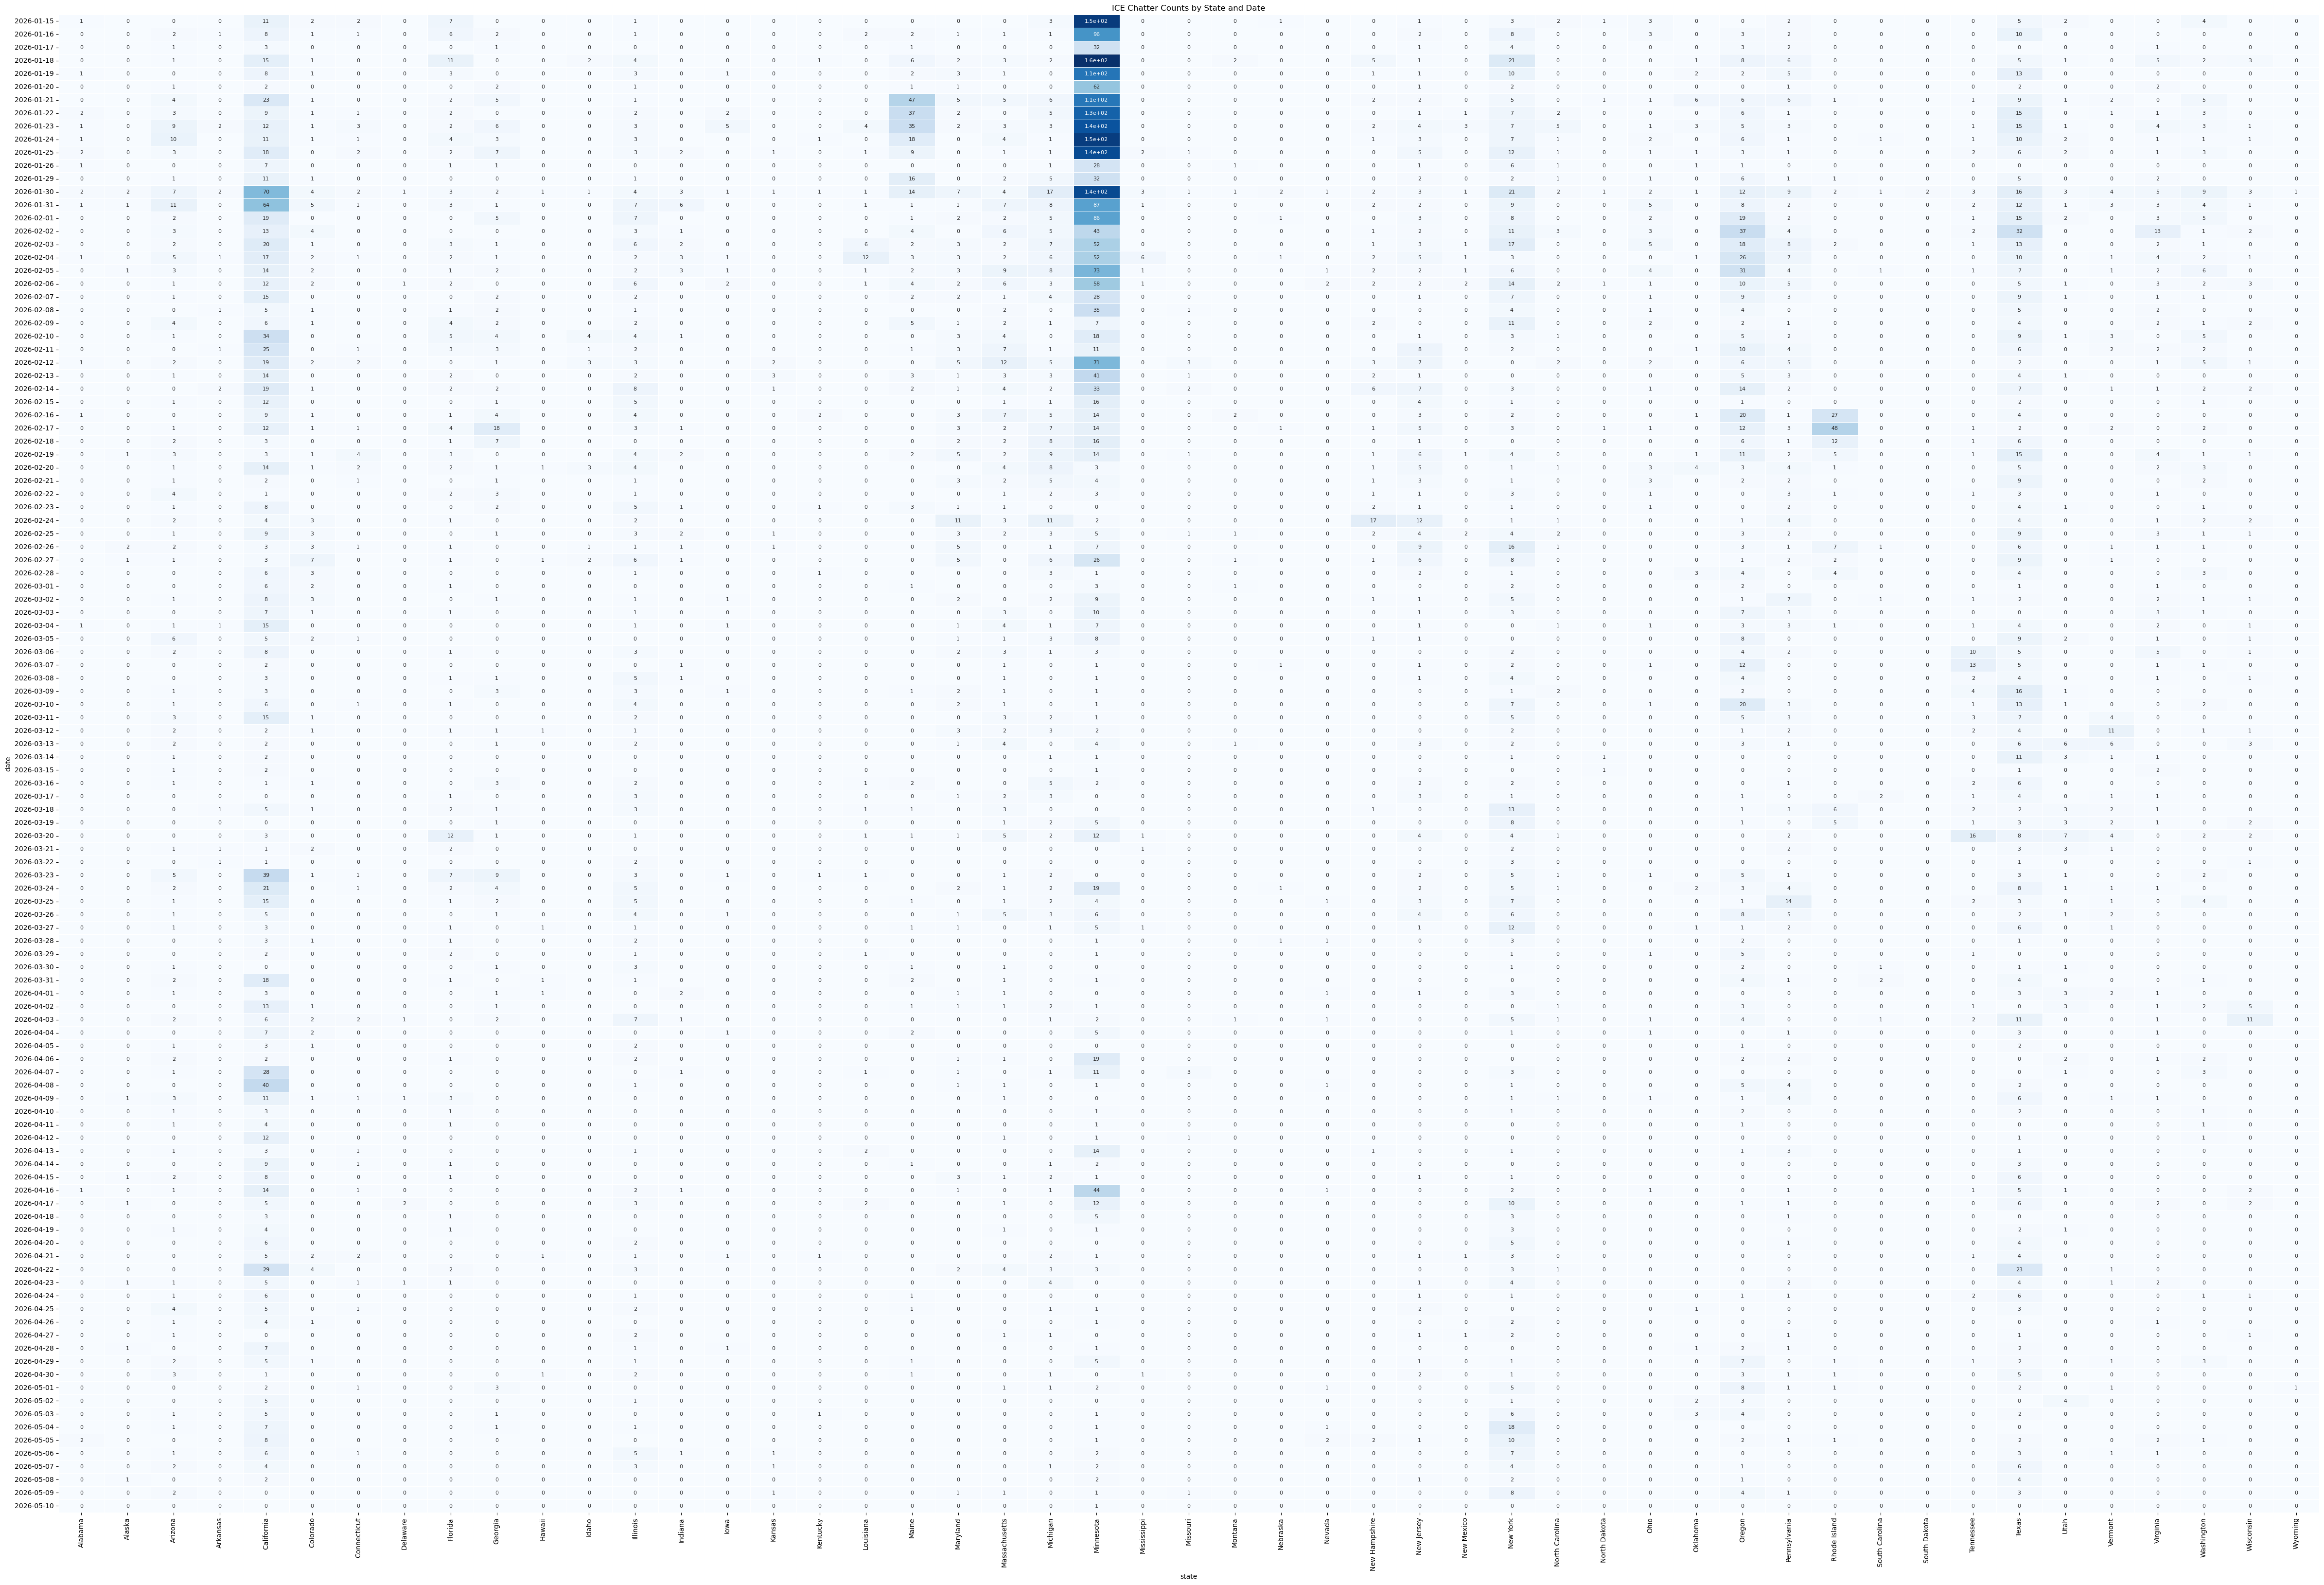

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(60, 40))
sns.heatmap(pvt_df, annot=True, cmap='Blues', linewidths=0.5, cbar=False, annot_kws={"size": 8})
plt.title('ICE Chatter Counts by State and Date')
plt.show()

# wanted to try seaborn approach from https://100daysofnetworks.substack.com/p/day-39-of-100daysofnetworks
# not interactive, less useful, but visually useful

# Today's Investigation Questions

- What are the spikes? (we will do this today)
- Do the states correlate with other states? (another day)
- Can we capture the spikes using Anomaly Detection (Isolation Forests, etc)? (another day)
- Can we predict when they are going to happen before they happen? (another day)

In [15]:
pvt_df.head()

state,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2026-01-15,1,0,0,0,11,2,2,0,7,0,...,0,0,0,5,2,0,0,4,0,0
2026-01-16,0,0,2,1,8,1,1,0,6,2,...,0,0,0,10,0,0,0,0,0,0
2026-01-17,0,0,1,0,3,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
2026-01-18,0,0,1,0,15,1,0,0,11,0,...,0,0,0,5,1,0,5,2,3,0
2026-01-19,1,0,0,0,8,1,0,0,3,0,...,0,0,0,13,0,0,0,0,0,0


<Axes: xlabel='date'>

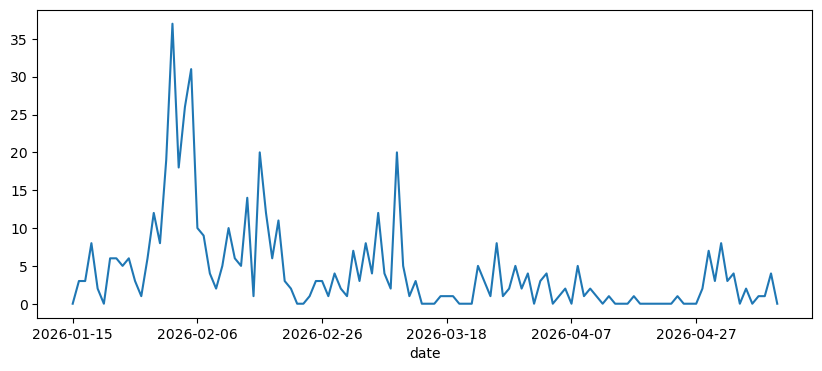

In [16]:
pvt_df['Oregon'].plot(figsize=(10,4))

<Axes: xlabel='date'>

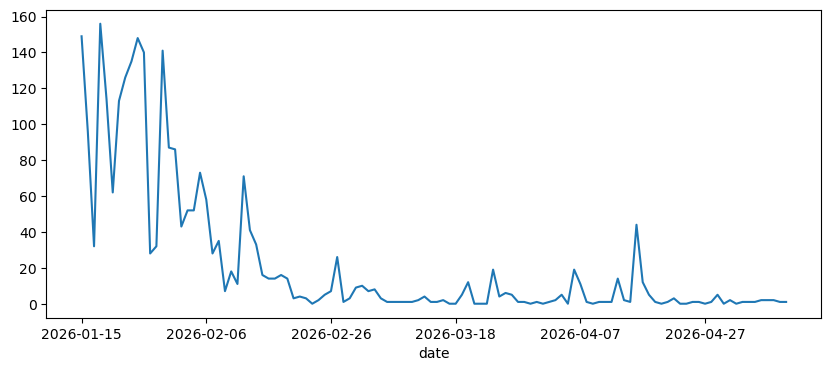

In [17]:
pvt_df['Minnesota'].plot(figsize=(10,4))

<Axes: xlabel='date'>

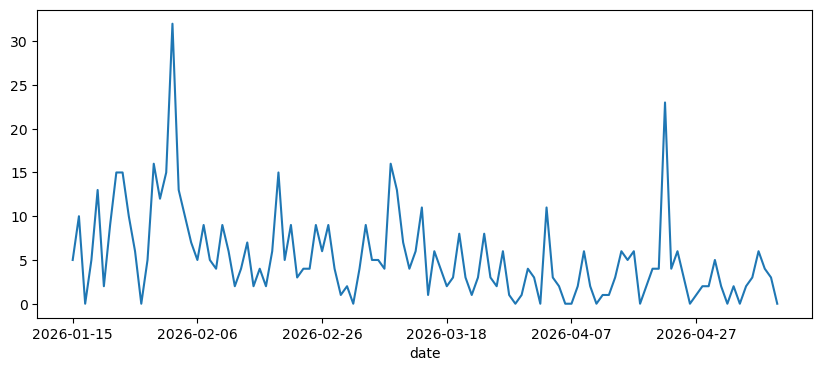

In [18]:
pvt_df['Texas'].plot(figsize=(10,4))

# What is a Spike?

Looking at each of the three graphs, let's say that a spike is any day with 15 or more claims of ICE activity. Let's do the labeling even without Machine Learning. KISS.

In [19]:
spike_pvt_df = (pvt_df>=15).astype(int)
spike_pvt_df

state,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,Wisconsin,Wyoming
date,,,,,,,,,,,,,,,,,,,,,
2026-01-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-01-16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-01-17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-01-18,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-01-19,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-06,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-07,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2026-05-08,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


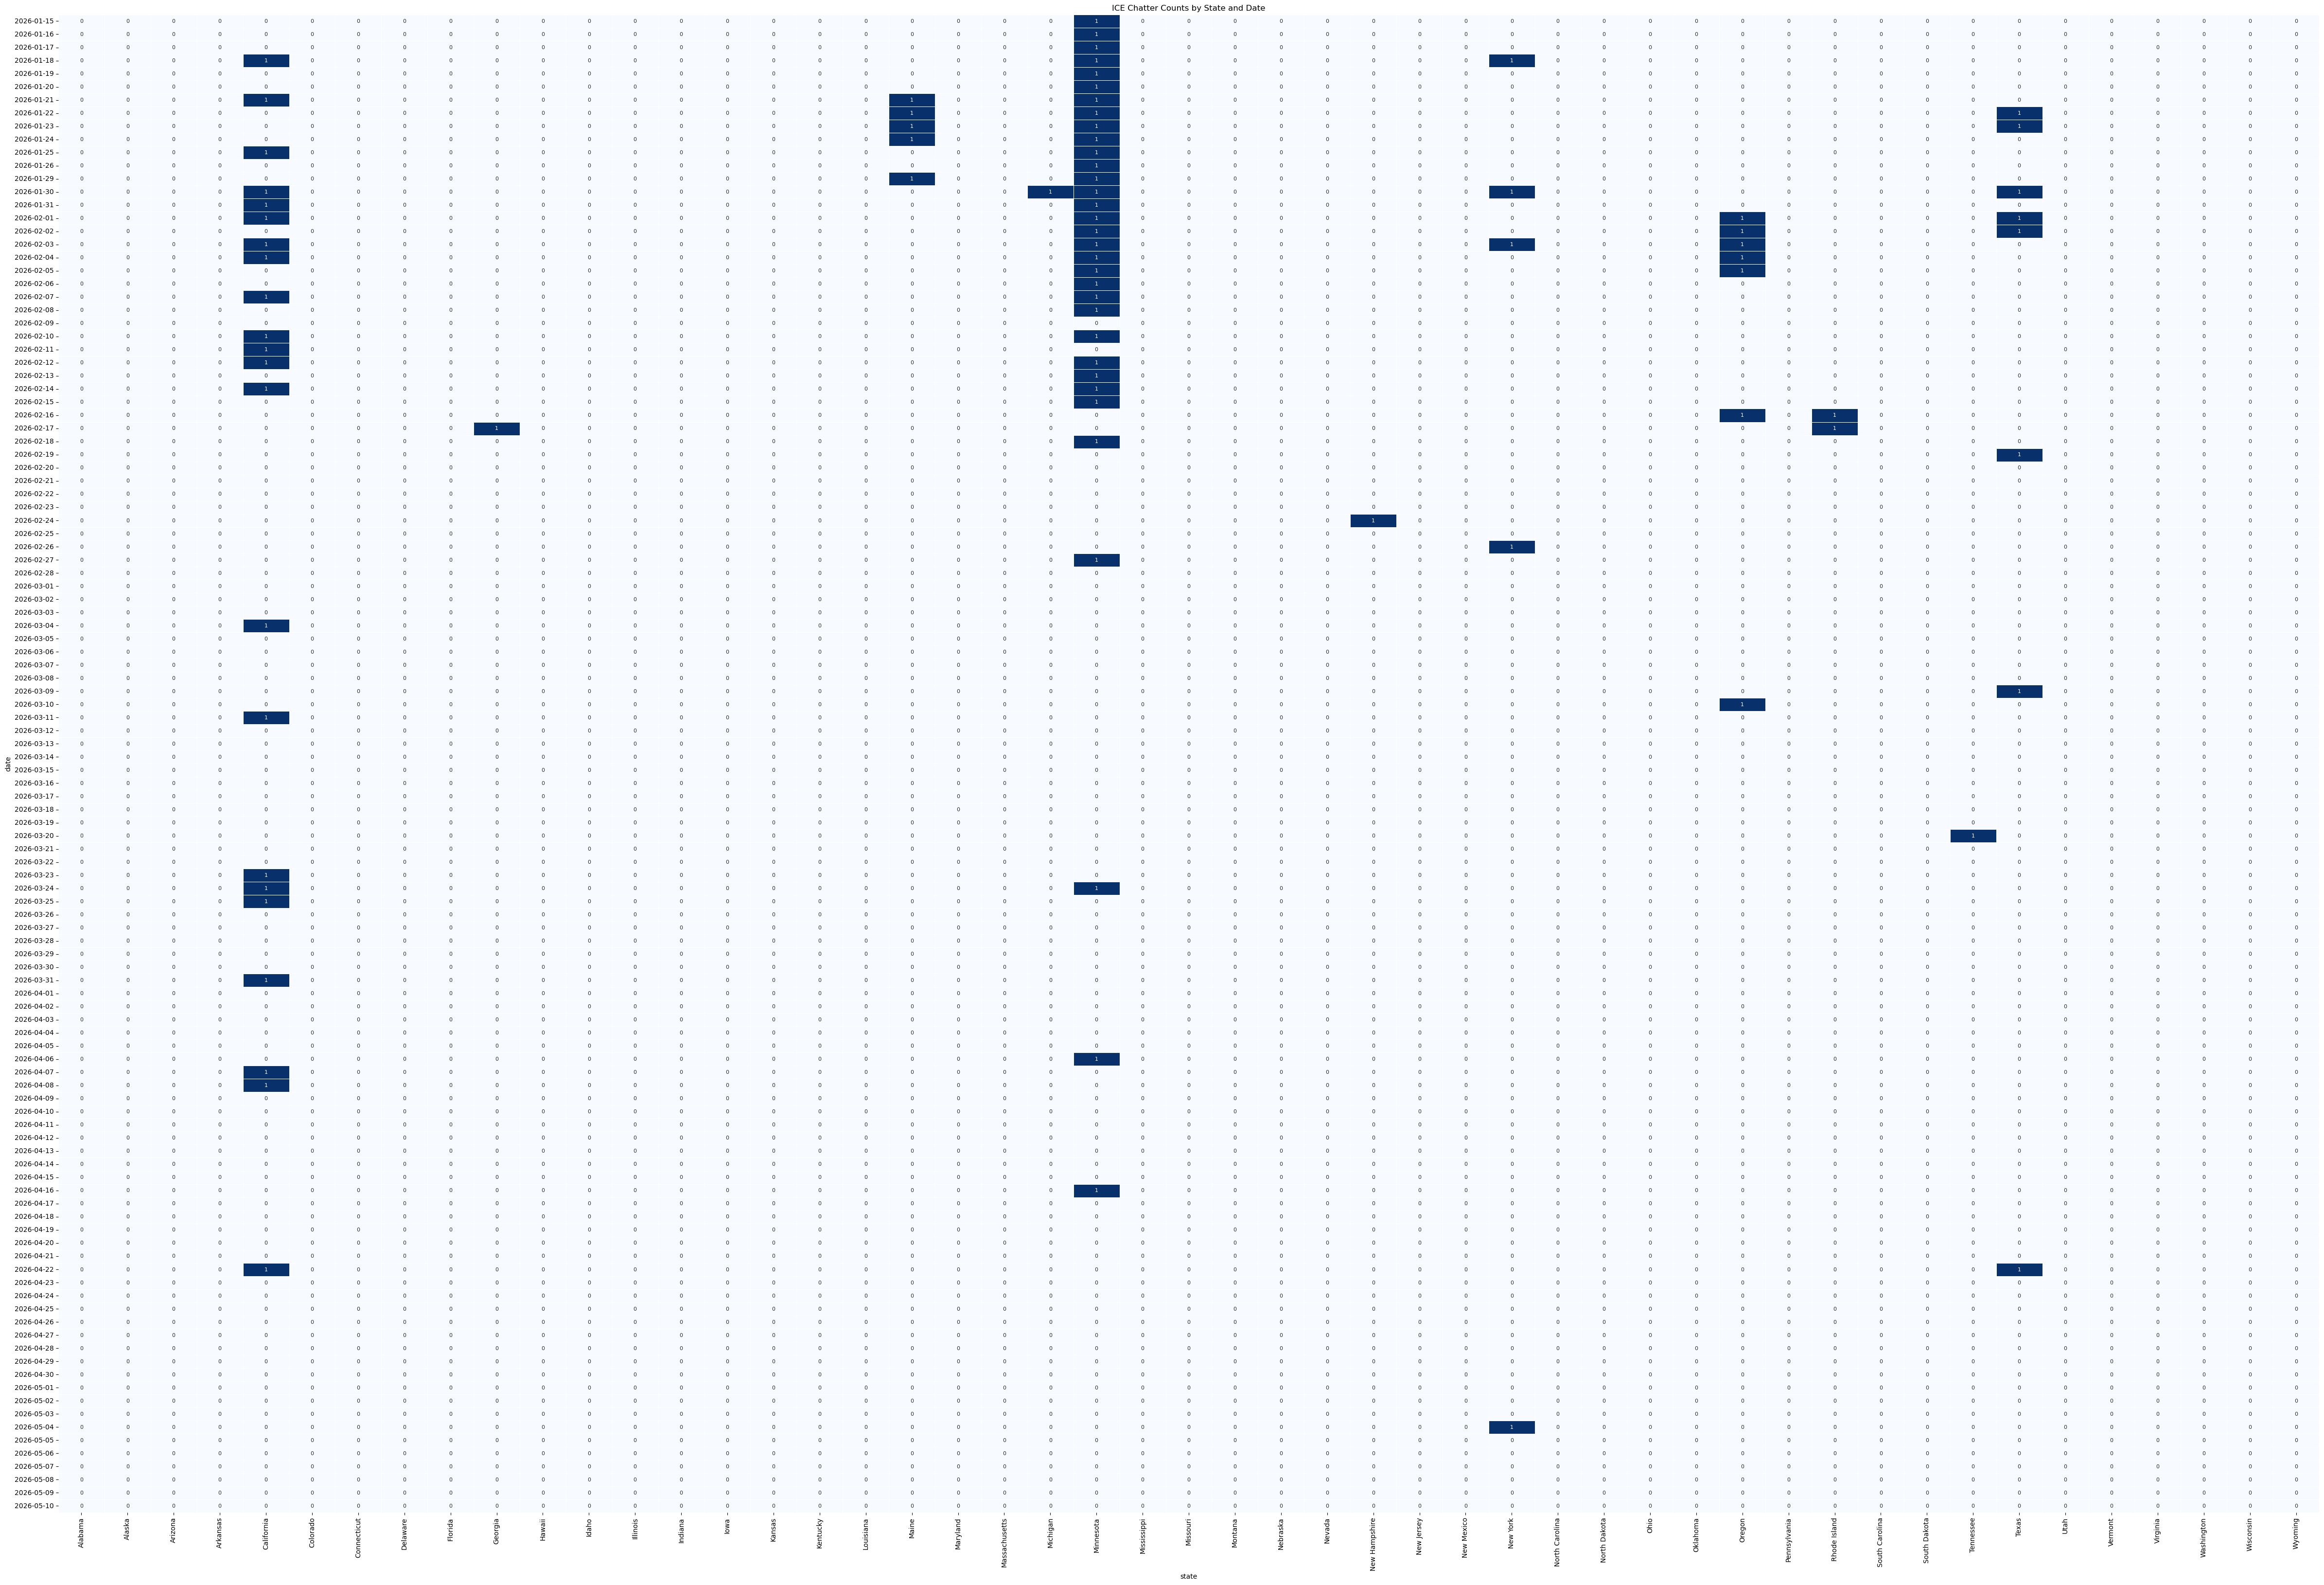

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(60, 40))
sns.heatmap(spike_pvt_df, annot=True, cmap='Blues', linewidths=0.5, cbar=False, annot_kws={"size": 8})
plt.title('ICE Chatter Counts by State and Date')
plt.show()

That's useful for seeing what is happening across the country very quickly. The number 15 can be decreased and more blue will show. It can be tuned, in other words.

<Axes: xlabel='date'>

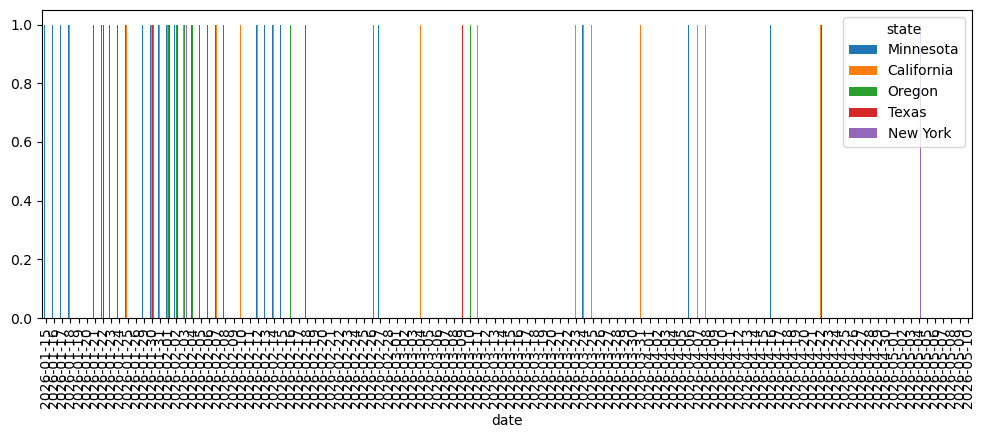

In [21]:
spike_pvt_df[states].plot.bar(figsize=(12,4))

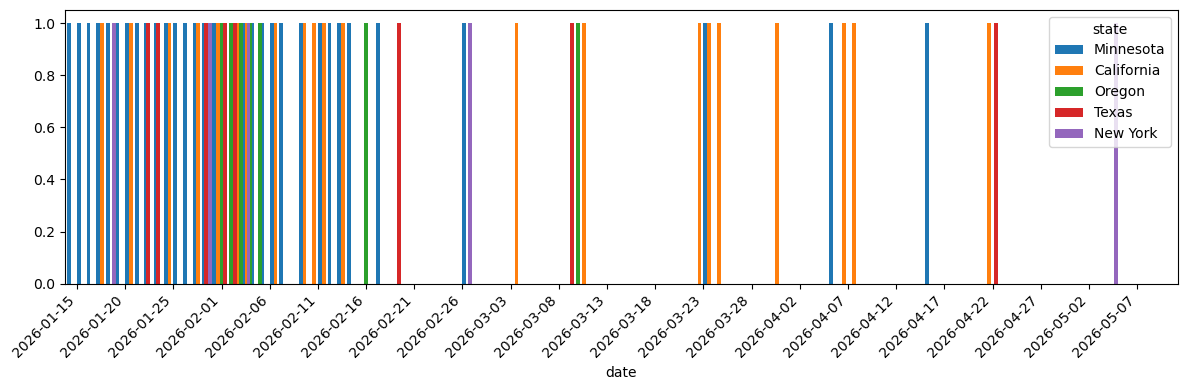

In [22]:
# claude wrote this to make things a little easier to read; thanks claude
# i recommend using AI for quickly getting through visualization headaches

fig, ax = plt.subplots(figsize=(12, 4))

spike_pvt_df[states].plot.bar(ax=ax, width=2)

n = max(1, len(spike_pvt_df) // 20)
ticks = range(0, len(spike_pvt_df), n)
ax.set_xticks(ticks)
ax.set_xticklabels(
    [str(spike_pvt_df.index[i])[:10] for i in ticks],
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

# What Recent Spikes?

This is an unusual visualization. In OSINT, I just want to see what is happening, and I'm not aiming for the sexiest visualizations in the world. Getting the data is the hard part. For visualization, you only need what you need.

This is enough to see that:
- There was A LOT more activity at the beginning of the year than now
- It is easy to see if things begin to heat up again
- The most recent spike was in New York around May 7
- Before that, there were two around May 22 in California and Texas

And so on. What stands out to me is the amount of orange. One of the questions had to do with correlation between states, but I don't see it in this image, so I'm not going to explore that today. The spikes are more interesting and useful.

# Verdant Eye API

I'll use my World AI to try to understand what is happening. It takes natural language as input and returns a dataset, which is ideal for AI Agents that need world awareness.

In [23]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

In [24]:
# for visualization
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix
import numpy as np

def draw_graph(G, show_names=False, node_size=1, font_size=10, edge_width=0.5):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores = scores, edge_width=edge_width)
    
    return SVG(image)

In [25]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


In [26]:
question = 'what happened in Oregon on May 10, 2026?'

answer = ask_api(client, question)
len(answer)

52

In [27]:
answer[0:3]

[{'claim': 'Oregon DMV is warning about fake texts that threaten registration suspension.',
  'url': 'https://news3lv.com/news/nation-world/oregon-dmv-warns-of-fake-texts-threatening-registration-suspension-unless-you-pay',
  'domain': 'news3lv.com',
  'url_domain': 'news3lv.com',
  'date_added': '2026-05-10 20:03:18'},
 {'claim': 'Cops arrested a former officer in connection with an apartment assault in Beaverton.',
  'url': 'https://hoodline.com/news/portland//2026/05/cops-ex-nabbed-in-beaverton-after-sw-portland-apartment-assault/',
  'domain': 'hoodline.com/news/portland/',
  'url_domain': 'hoodline.com/news/portland/',
  'date_added': '2026-05-10 19:46:38'},
 {'claim': 'An indictment has been filed related to the killing of Shiloh Thanos Young in NW Portland.',
  'url': 'https://hoodline.com/news/portland//2026/05/jailhouse-indictment-filed-in-nw-portland-killing-of-shiloh-thanos-young/',
  'domain': 'hoodline.com/news/portland/',
  'url_domain': 'hoodline.com/news/portland/',
  '

In [28]:
question = 'what did ICE do in New York in May 2026?'

answer = ask_api(client, question)
len(answer)

46

In [29]:
claim_df = pd.DataFrame(answer)
claim_df.head()

,claim,url,domain,url_domain,date_added
0,NYC detectives' union advocates for NYPD inclu...,https://us.headtopics.com/news/nyc-detectives-...,headtopics.com,us.headtopics.com,2026-05-09 20:49:17
1,An Albany mother was released from ICE custody...,https://hoodline.com/news/seattle//2026/05/alb...,hoodline.com/news/seattle/,hoodline.com/news/seattle/,2026-05-09 20:45:12
2,The NYC detectives union is advocating for the...,https://nypost.com/2026/05/09/us-news/nyc-dete...,nypost.com,nypost.com,2026-05-09 20:32:29
3,Indignation in the Bronx as alleged ICE agents...,https://mx.headtopics.com/news/indignaci-n-en-...,headtopics.com,mx.headtopics.com,2026-05-09 20:01:11
4,ICE mistakenly detains a young man in the Bron...,https://laopinion.com/2026/05/09/ice-detiene-p...,laopinion.com,laopinion.com,2026-05-09 18:00:27


In [30]:
import networkx as nx

G = nx.from_pandas_edgelist(claim_df, source='domain', target='url_domain')
print(G)

Graph with 43 nodes and 36 edges


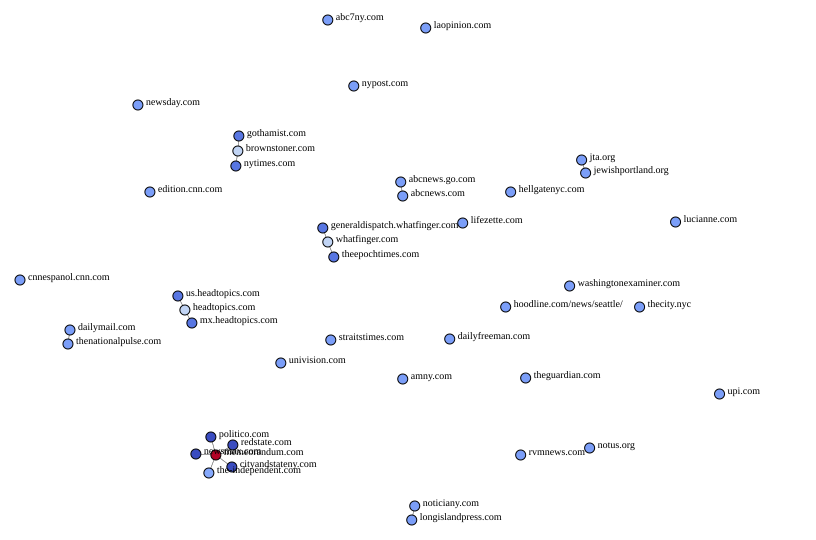

In [31]:
draw_graph(G, node_size=5, show_names=True)

# This is a Lot Already, Let's Cluster!

This has already been so insightful and I can see a lot that can be explored. I can see what looks like information warfare in here without even looking closely, but we will investigate clusters to determine if that is true.

In [32]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

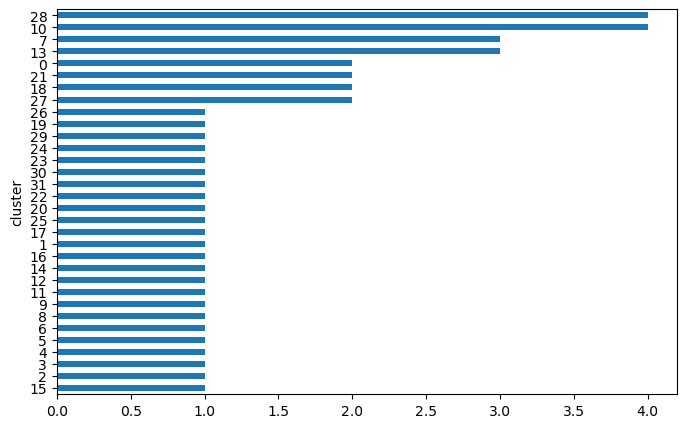

In [55]:
claim_df['cluster'] = cluster_text(claim_df['claim'], similarity_threshold=0.2) # very low to get any clusters
claim_df['cluster'].value_counts()[0:50].plot.barh(figsize=(8,5)).invert_yaxis()

In [35]:
top_clusters = claim_df['cluster'].value_counts()[0:20].index.values
top_clusters

array([28, 10,  7, 13,  0, 21, 18, 27, 26, 19, 29, 24, 23, 30, 31, 22, 20,
       25, 17,  1], dtype=int64)

In [36]:
cluster = top_clusters[0]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# interesting. only one is claiming that ICE watchdogs incided violence. is it a biased source?

array(['Social media posts from ICE watchdogs incited a violent protest outside a NYC hospital.',
       'ICE arrests during a protest outside a NYC hospital',
       '8 people arrested during protest against ICE in Brooklyn',
       'Rally against ICE in Hempstead, Long Island'], dtype=object)

In [37]:
claim_df[claim_df['cluster']==cluster].head(20) # yes, it is New York Post

,claim,url,domain,url_domain,date_added,cluster
28,Social media posts from ICE watchdogs incited ...,https://nypost.com/2026/05/04/us-news/flurry-o...,nypost.com,nypost.com,2026-05-04 20:07:21,28
29,ICE arrests during a protest outside a NYC hos...,https://www.nytimes.com/2026/05/03/nyregion/ic...,brownstoner.com,nytimes.com,2026-05-04 20:03:40,28
38,8 people arrested during protest against ICE i...,https://abcnews.com/US/8-people-arrested-prote...,abcnews.go.com,abcnews.com,2026-05-03 21:45:47,28
42,"Rally against ICE in Hempstead, Long Island",https://newsday.com/long-island/nassau/anti-ic...,newsday.com,newsday.com,2026-05-01 22:24:32,28


In [38]:
cluster = top_clusters[1]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# interesting. only one is attaching the word "Socialist" to Mamdani. is it a biased source?
# that title is a manipulation of their readers

array(["Zohran Mamdani raises concerns about the NYPD's collaboration with ICE.",
       'Socialist Mayor Mamdani criticizes ICE after a chaotic protest in Brooklyn.',
       'Mayor Zohran Mamdani criticizes ICE following a chaotic protest in Brooklyn.',
       'Protesters clashed with ice police in Brooklyn involving Zohran Mamdani.'],
      dtype=object)

In [39]:
claim_df[claim_df['cluster']==cluster].head(20) # yes, it is Newsmax

,claim,url,domain,url_domain,date_added,cluster
13,Zohran Mamdani raises concerns about the NYPD'...,https://www.newsmax.com/newsfront/zohran-mamda...,memeorandum.com,newsmax.com,2026-05-06 21:26:08,10
18,Socialist Mayor Mamdani criticizes ICE after a...,https://www.rvmnews.com/2026/05/socialist-mayo...,rvmnews.com,rvmnews.com,2026-05-05 20:02:15,10
23,Mayor Zohran Mamdani criticizes ICE following ...,https://www.lifezette.com/2026/05/socialist-ma...,lifezette.com,lifezette.com,2026-05-05 18:33:26,10
27,Protesters clashed with ice police in Brooklyn...,https://theguardian.com/us-news/2026/may/04/zo...,theguardian.com,theguardian.com,2026-05-04 21:34:46,10


In [40]:
cluster = top_clusters[2]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# this looks neutral

array(['Tom Homan warns Kathy Hochul that blocking ICE will lead to increased presence of immigration enforcement in New York.',
       "Tom Homan's statements regarding ICE's role in New York's immigration policies are highlighted.",
       'Tom Homan discusses immigration issues with ICE in New York.'],
      dtype=object)

In [41]:
cluster = top_clusters[3]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# this looks neutral

array(['Claims that an individual was detained by ICE at a hospital in New York',
       'Protests erupt following the detention of a man by ICE at a hospital in New York.',
       'Arrest by ICE at a New York hospital sparks protests and tension in Brooklyn.'],
      dtype=object)

In [42]:
cluster = top_clusters[4]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# this looks neutral

array(["NYC detectives' union advocates for NYPD inclusion in ICE",
       "The NYC detectives union is advocating for the NYPD's involvement in the ICE Buffer Zone Act."],
      dtype=object)

In [43]:
cluster = top_clusters[5]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# this looks neutral

array(['New details emerge about an ICE operation in a Brooklyn hospital involving hooded agents, pepper spray, and injuries among New Yorkers and police.',
       'ICE operation in Brooklyn causes protests and complaints'],
      dtype=object)

In [44]:
cluster = top_clusters[6]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# this looks neutral

array(['Claims a detainee was dragged to a hospital by ICE in Brooklyn, NYC',
       'Chidozie Wilson Okeke was arrested by ICE in Brooklyn, New York.'],
      dtype=object)

In [45]:
cluster = top_clusters[7]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# this looks neutral

array(['An ICE raid at a Brooklyn hospital led to significant protests and clashes.',
       'ICE agents conducted a raid at a Brooklyn hospital'], dtype=object)

In [46]:
cluster = top_clusters[8]

claim_df[claim_df['cluster']==cluster].head(20)['claim'].values

# this looks neutral

array(['ICE enforcement action has triggered protests leading to 9 arrests at a NYC hospital'],
      dtype=object)

# Biased Sources

Out of the clusters we have looked at, two biased sources revealed themselves. Loaded languages is a dead giveaway. Let's look at their networks to see what these two sources link to? Maybe they will point to other interesting content.

In [47]:
subset_df = claim_df[claim_df['url_domain'].isin(['nypost.com', 'newsmax.com', 'memeorandum.com	'])]
subset_df

,claim,url,domain,url_domain,date_added,cluster
2,The NYC detectives union is advocating for the...,https://nypost.com/2026/05/09/us-news/nyc-dete...,nypost.com,nypost.com,2026-05-09 20:32:29,0
6,Report on ICE actions in New York involving Go...,https://www.newsmax.com/newsfront/ice-new-york...,memeorandum.com,newsmax.com,2026-05-08 08:04:08,5
13,Zohran Mamdani raises concerns about the NYPD'...,https://www.newsmax.com/newsfront/zohran-mamda...,memeorandum.com,newsmax.com,2026-05-06 21:26:08,10
15,The piece covers NYC groups of Gen Z agitators...,https://nypost.com/2026/05/06/us-news/inside-n...,nypost.com,nypost.com,2026-05-06 10:31:14,12
28,Social media posts from ICE watchdogs incited ...,https://nypost.com/2026/05/04/us-news/flurry-o...,nypost.com,nypost.com,2026-05-04 20:07:21,28


It's not even worth visualizing this, but let's see what else these domains have to say about ICE activity.

In [48]:
question = 'what does nypost.com say about ICE?'

answer = ask_api(client, question)
len(answer)

272

In [49]:
answer_df = pd.DataFrame(answer)
sorted(answer_df['claim'])[0:20]

['300 students were suspended for participating in an anti-ICE walkout',
 "A 5-year-old boy and his father were taken into custody by ICE in Minneapolis but were later released following a judge's order.",
 'A California man broke into a jail to evade ICE agents.',
 'A Cuban immigrant died while in ICE custody due to homicide asphyxia, according to an autopsy.',
 "A Democratic Socialist House candidate's rival has received donations linked to a protest against ICE monitors.",
 'A LA neighborhood has installed anti-ICE sirens to alert residents.',
 'A LA teacher was fired for allowing students to join an anti-ICE walkout.',
 'A Long Island high school teacher allegedly threatened to call ICE while supervising a classroom containing many Hispanic students.',
 'A Minneapolis driver shot by ICE was stalking and impeding law enforcement.',
 'A Minnesota dad became a key figure in anti-ICE protests but later confronted a journalist from Turning Point USA.',
 'A NYC council staffer was detain

In [50]:
question = 'what does newsmax.com say about ICE?'

answer = ask_api(client, question)
len(answer)

63

In [51]:
answer_df = pd.DataFrame(answer)
sorted(answer_df['claim'])[0:20]

["A judge's ruling affects DHS and ICE operations.",
 'A lawsuit in Minnesota regarding ICE raids is being reported.',
 "Adrian Conejo-Arias's story highlights issues surrounding ICE and immigration enforcement.",
 'An ICE reporter is involved in a situation in Minneapolis.',
 'An article discussing an ICE judge named Liam Ramos.',
 'Claim about a massacre involving ICE.',
 'Claims about ICE warehouses under the Trump administration.',
 'Claims of excessive force by ICE and CBP agents',
 'Coverage of an incident involving Markwayne Mullin and ICE after a shooting.',
 'Coverage of protests against ICE following a shooting in Minneapolis.',
 'Coverage of the Minneapolis ICE shooting.',
 'DHS and ICE are employing facial recognition technology.',
 'DHS is facing scrutiny in the Senate regarding ICE policies',
 'DHS reports gang arrests by ICE',
 "Denver's Mike Johnston addresses concerns regarding ICE and immigration policies",
 "Details on ICE's recruiting advertisement campaign.",
 'Dis

# Back to the Spike

Let's Get Back to the Spike. There was a spike in New York in May 2026, so let's look at everything that is included. We already looked at clusters.

In [52]:
sorted(claim_df['claim'])

['8 people arrested during protest against ICE in Brooklyn',
 'A Nigerian immigrant is suing ICE following his arrest which led to protests in Brooklyn.',
 'A married couple from Manhattan reunites after one of them is detained by ICE.',
 'A protest in NYC regarding ICE turned chaotic, leading to police arrests of a Nigerian national who used a weaponized vehicle against agents.',
 'An Albany mother was released from ICE custody after being snatched while running a soccer errand.',
 'An ICE raid at a Brooklyn hospital led to significant protests and clashes.',
 'Arrest by ICE at a New York hospital sparks protests and tension in Brooklyn.',
 'Article addressing issues regarding ICE at Wyckoff Heights Medical Center and NYPD.',
 'Chidozie Wilson Okeke was arrested by ICE in Brooklyn, New York.',
 'Claims a detainee was dragged to a hospital by ICE in Brooklyn, NYC',
 'Claims that State Senator Skoufis is reacting to potential new state-wide ICE restrictions in New York',
 'Claims that a

In [54]:
# This is what is happening in New York
# I have World AI. It is useful to journalists, scientists, and capable engineers